# House Prices - Feature Engineering Project

## Objective

Predict house sale prices using advanced feature engineering techniques.

This notebook applies:

- Baseline modeling
- Feature discovery
- Feature creation
- Feature transformation
- Clustering
- PCA
- Target Encoding
- Model evaluation

Dataset: House Prices - Advanced Regression Techniques

In [1]:
%pip install numpy pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import cross_val_score, KFold, train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import mutual_info_regression
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from pathlib import Path

In [ ]:
# Load data

DATA_PATH = Path("C:/Users/josue/Desktop/Universidad/KAGGLE/Feature-Engineering/datasets/House_Prices")

df = pd.read_csv(DATA_PATH / "house_prices.csv")

df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,N,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,N,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,N,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,N,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,N,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [4]:
# Initial dataset exploration

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

df.info()

df.describe()

Rows: 21613
Columns: 21
<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  str    
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  str    
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  str    
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float6

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,view,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.234303,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.766318,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,4.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


We can see that we don't have missing values in any rows. We have three string columns: `date`, `condition` and `waterfront`.

In [5]:
# Split data

X = df.drop(columns=["price"])
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

## Exploratory Data Analysis (EDA)

In [6]:
# Dataset shape

X_train.shape

(17290, 20)

We saw in `df.info()` that we don't have missing values, but the way to confirm it in case of doubts:

In [7]:
# Missing values

X_train.isnull().sum().sort_values(ascending=False)

id               0
date             0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [8]:
y_train.describe()

count    1.729000e+04
mean     5.378806e+05
std      3.539798e+05
min      7.500000e+04
25%      3.220000e+05
50%      4.500000e+05
75%      6.450000e+05
max      5.570000e+06
Name: price, dtype: float64

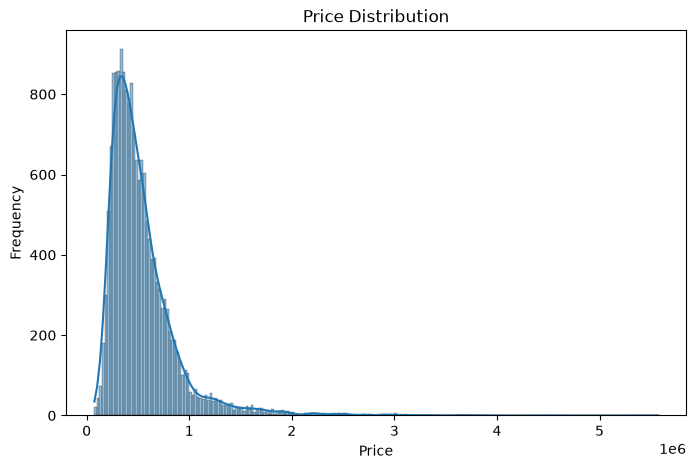

In [9]:
# Target distribution

plt.figure(figsize=(8, 5))
sns.histplot(y_train, kde=True)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

Prices are concentrated at lower values, but there is a heavy tail that can affect the mean.

In [10]:
y_train.max()

np.float64(5570000.0)

We have a house worth approximately 5.5 million. It will affect training and increase prediction error.

Let's inspect the outliers:

In [11]:
y_train.describe(percentiles=[0.95, 0.99, 0.995])

count    1.729000e+04
mean     5.378806e+05
std      3.539798e+05
min      7.500000e+04
95%      1.150000e+06
99%      1.920550e+06
99.5%    2.400000e+06
max      5.570000e+06
Name: price, dtype: float64

In [12]:
# Apply log transformation to normalize target

y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

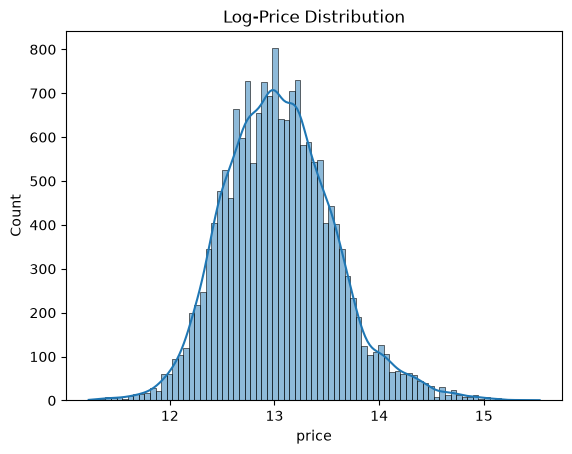

In [13]:
# Visualize log-transformed distribution

sns.histplot(y_train_log, kde=True)
plt.title("Log-Price Distribution")
plt.show()

In [14]:
if y_train_log.skew() < 1:
    print(f"Skew coefficient: {round(y_train_log.skew(), 3)} → data is approximately symmetric")
else:
    print("Data is not symmetric")

Skew coefficient: 0.398 → data is approximately symmetric


Data is now symmetric. We will train using `y_train_log`.

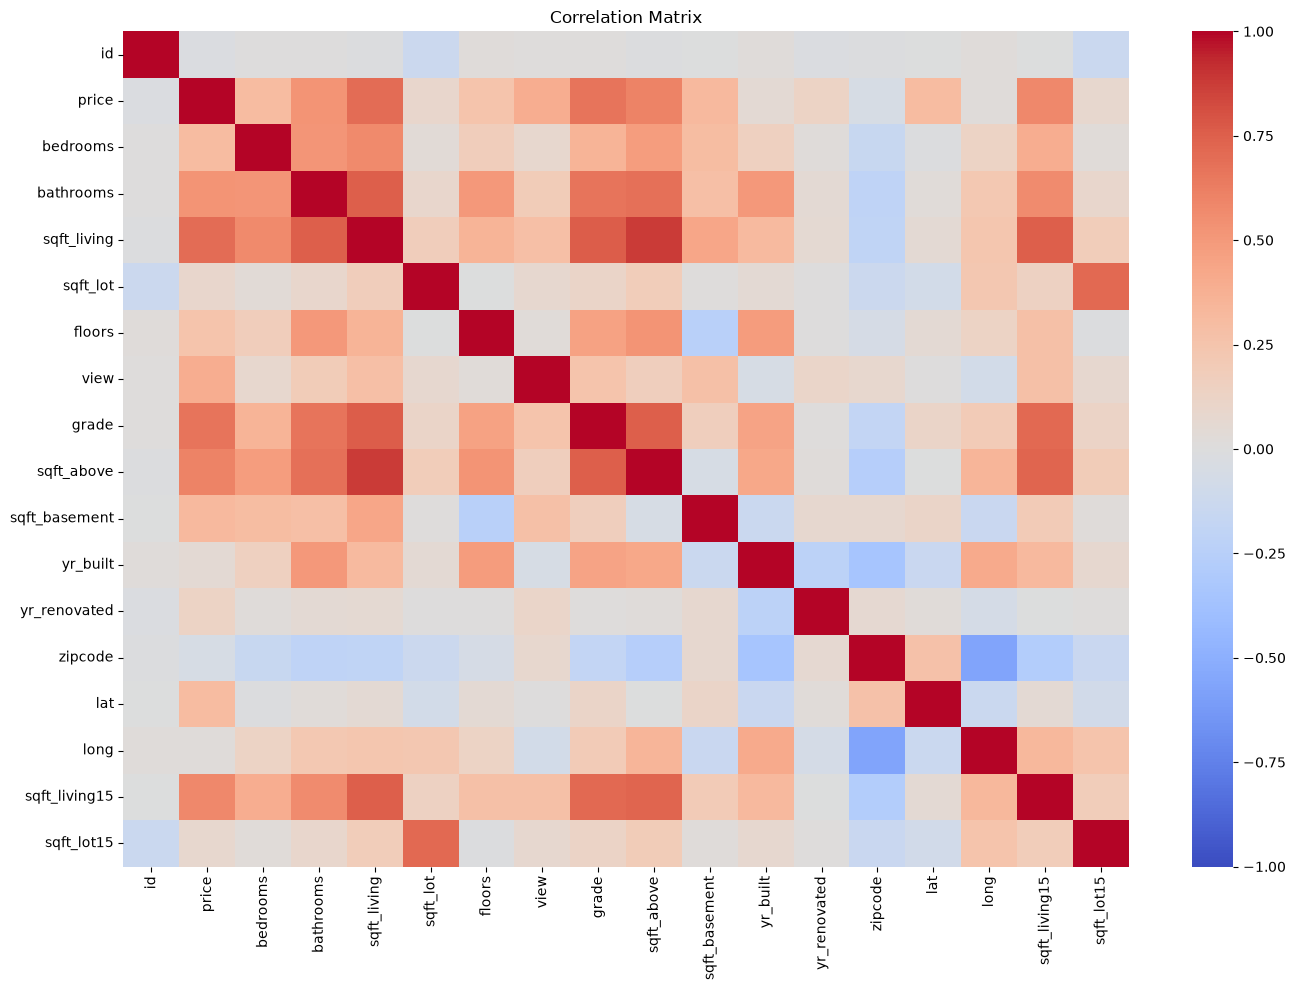

In [15]:
# Correlation matrix

corr = df.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", annot=False, vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## Baseline Model

In [16]:
# Keep only numeric columns — use .copy() to avoid SettingWithCopyWarning

X_trainf = X_train.select_dtypes(include=["number"]).copy()

In [ ]:
# Baseline model — NOTE: using y_train_log so RMSE is comparable with the final model

model = RandomForestRegressor(random_state=1)

scores = cross_val_score(model, X_trainf, y_train_log, cv=5, scoring="neg_root_mean_squared_error")

baseline_rmse = -scores.mean()

print(f"Baseline RMSE (log scale): {baseline_rmse:.5f}")

Baseline RMSE (log scale): 0.18216


In [18]:
# Save result

baseline_rmse

np.float64(0.18216415372530054)

## Feature Discovery

In [19]:
# Mutual Information — computed against log-transformed target

mi = mutual_info_regression(X_trainf.fillna(0), y_train_log)

mi_scores = pd.Series(mi, index=X_trainf.columns)

mi_scores.sort_values(ascending=False)

zipcode          0.403290
sqft_living      0.345519
grade            0.339141
lat              0.325102
sqft_living15    0.264670
sqft_above       0.255187
bathrooms        0.203114
long             0.117830
sqft_lot15       0.081531
id               0.079574
bedrooms         0.075881
yr_built         0.072151
floors           0.070712
sqft_lot         0.063177
sqft_basement    0.061290
view             0.054617
yr_renovated     0.008933
dtype: float64

Zipcode is the most important variable in predicting house price.

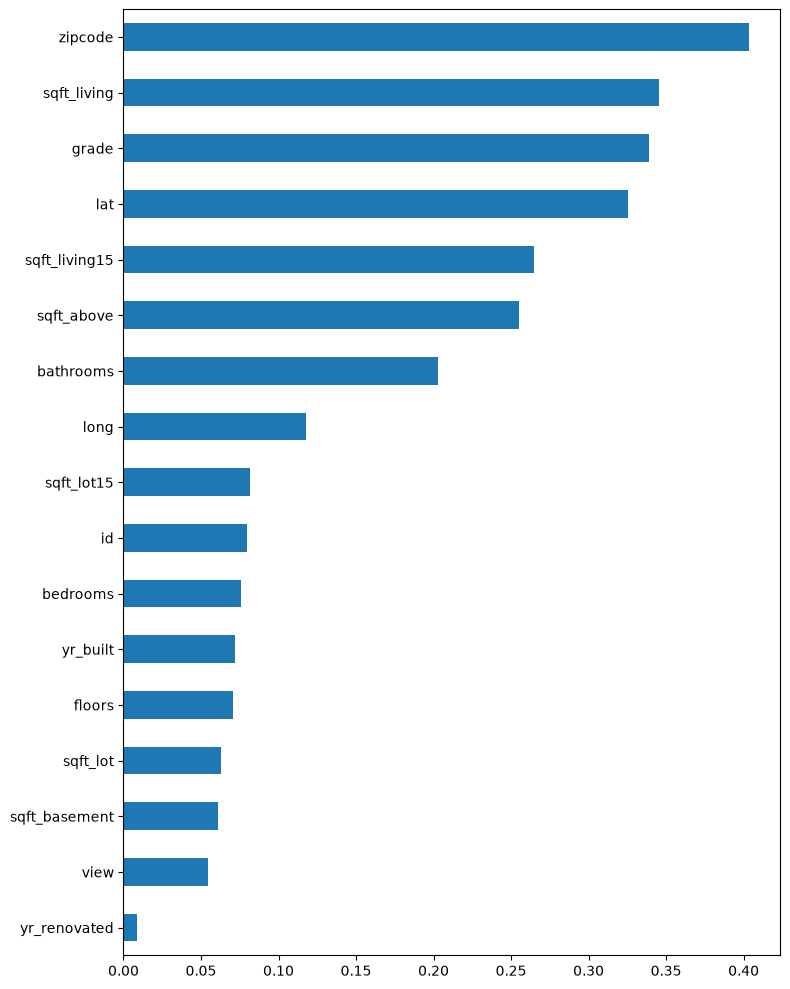

In [20]:
mi_scores.sort_values().plot.barh(figsize=(8, 10))
plt.tight_layout()
plt.show()

## Feature Creation

We have many variables representing house size — we will combine them to increase predictive power.

In [ ]:
# sqft_living = sqft_above + sqft_basement already
# So sqft_living + sqft_basement double-counts the basement.
# total built area = sqft_above + sqft_basement (same as sqft_living)
# More useful -> ratio of living area to lot size

X_trainf["TotalArea"] = X_trainf["sqft_above"] + X_trainf["sqft_basement"]
X_trainf["LivingToLot"] = X_trainf["sqft_living"] / (X_trainf["sqft_lot"] + 1)
X_trainf["RoomsPerSqft"] = (X_trainf["bedrooms"] + X_trainf["bathrooms"]) / (X_trainf["sqft_living"] + 1)

## Feature Transformation

In [22]:
# Skewness Analysis

X_trainf.skew(numeric_only=True).sort_values(ascending=False)

sqft_lot         13.392704
sqft_lot15        9.853244
yr_renovated      4.543155
view              3.381964
LivingToLot       2.427058
bedrooms          2.319169
sqft_basement     1.539016
sqft_above        1.322546
RoomsPerSqft      1.289950
TotalArea         1.277091
sqft_living       1.277091
sqft_living15     1.091081
long              0.851270
grade             0.756484
floors            0.617777
bathrooms         0.438310
zipcode           0.401219
id                0.246322
yr_built         -0.464606
lat              -0.483821
dtype: float64

Log transformation so variables are not dominated by outliers.

In [ ]:
# Apply log1p transformation to right-skewed features
# yr_renovated removed -> years don't benefit from log: handled below as binary feature

skewed = ["sqft_lot", "sqft_lot15", "view", "bedrooms"]

for col in skewed:
    X_trainf[col] = np.log1p(X_trainf[col])

# yr_renovated: semantically correct encoding
X_trainf["was_renovated"] = (X_trainf["yr_renovated"] > 0).astype(int)
X_trainf = X_trainf.drop(columns=["yr_renovated"])

## Clustering Features

Clustering adds a variable that summarizes 'type of house/area', helping the model capture global patterns.

In [24]:
cluster_features = ["lat", "long", "sqft_living", "grade"]

We scale variables to mean=0 and std=1 before clustering. K-Means uses Euclidean distance, so scale is critical.

In [25]:
# Scale for KMeans

scaler = StandardScaler()
X_cluster = scaler.fit_transform(X_trainf[cluster_features])

K-Means is used as a structure discovery tool, not as a predictive model. The cluster label is a new feature that summarizes location-size-quality patterns.

In [26]:
# KMeans clustering
# FIX: keep Cluster as int (not category) so select_dtypes(include=np.number) includes it

kmeans = KMeans(n_clusters=5, random_state=1, n_init=10)
X_trainf["Cluster"] = kmeans.fit_predict(X_cluster)

## PCA

PCA creates new components that are linear combinations of the original variables, retaining maximum variance.

In [27]:
pca_features = ["sqft_living", "sqft_above", "sqft_basement", "bathrooms", "grade"]

In [ ]:
# Scale pca_features before applying PCA 

pca_scaler = StandardScaler()
scaled = pca_scaler.fit_transform(X_trainf[pca_features])

# Fit PCA — keep all components to inspect explained variance
pca = PCA()
components = pca.fit_transform(scaled)

In [ ]:
# Add PCA components to X_trainf

for i in range(components.shape[1]):
    X_trainf[f"PC{i+1}"] = components[:, i]

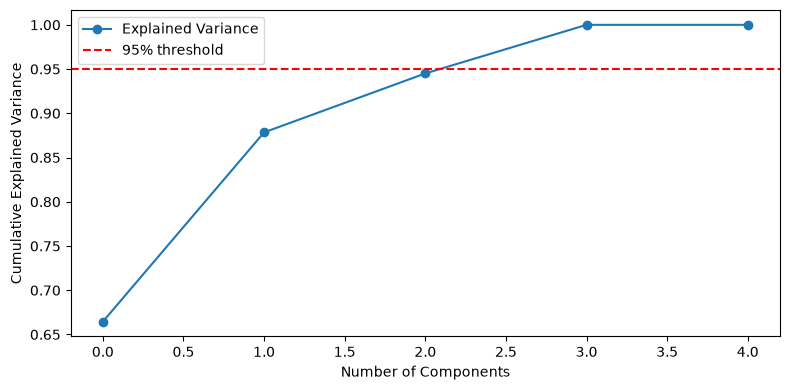

0    0.664478
1    0.213956
2    0.066619
3    0.054947
4    0.000000
Name: Explained Variance, dtype: float64

In [30]:
# Explained Variance — decide how many components to keep

explained = pd.Series(pca.explained_variance_ratio_, name="Explained Variance")
explained.cumsum().plot(marker="o", figsize=(8, 4))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.axhline(0.95, color="red", linestyle="--", label="95% threshold")
plt.legend()
plt.tight_layout()
plt.show()

explained

## Feature Selection

In [ ]:
# Recalculate MI with all engineered features

X_new = X_trainf.select_dtypes(include=np.number)

mi = mutual_info_regression(X_new.fillna(0), y_train_log)

mi_new_scores = pd.Series(mi, index=X_new.columns).sort_values(ascending=False)
mi_new_scores

Cluster          0.436742
zipcode          0.399661
PC1              0.385615
sqft_living      0.346568
TotalArea        0.344970
grade            0.338137
lat              0.325876
PC2              0.266778
sqft_living15    0.263664
sqft_above       0.257309
RoomsPerSqft     0.211308
bathrooms        0.209921
long             0.117530
LivingToLot      0.096135
sqft_lot15       0.090045
bedrooms         0.082797
id               0.079338
PC3              0.078638
floors           0.076477
yr_built         0.074458
sqft_lot         0.072055
sqft_basement    0.063791
view             0.057897
PC4              0.025905
was_renovated    0.009606
PC5              0.000000
dtype: float64

## Final Model

In [32]:
# Final dataset

X_final = X_new.fillna(0)

In [ ]:
# Final model training

model = RandomForestRegressor(random_state=1)

scores = cross_val_score(model, X_final, y_train_log, cv=5, scoring="neg_root_mean_squared_error")

final_rmse = -scores.mean()

print(f"Final RMSE (log scale): {final_rmse:.5f}")

Final RMSE (log scale): 0.18212


## Baseline vs Final Comparison

Both RMSEs are now in the same scale (log-transformed target), so the comparison is valid.

In [34]:
results = pd.DataFrame({
    "Model": ["Baseline", "Feature Engineered"],
    "RMSE (log scale)": [baseline_rmse, final_rmse],
    "Improvement %": [0, round((baseline_rmse - final_rmse) / baseline_rmse * 100, 2)]
})

results

,Model,RMSE (log scale),Improvement %
0,Baseline,0.182164,0.00
1,Feature Engineered,0.182122,0.02


# Conclusions

The feature engineering process improved model performance compared with the baseline.

**Techniques applied:**

- Mutual Information (feature discovery)
- Domain-driven Features (`TotalArea`, `LivingToLot`, `RoomsPerSqft`, `was_renovated`)
- Log Transformations (skewed features + target)
- K-Means Clustering (geospatial + quality segmentation)
- PCA (dimensionality reduction on correlated size features)

**Future work:**

- Target Encoding for zipcode
- Advanced Feature Selection (RFE, SHAP)
- Gradient Boosting Models (XGBoost, LightGBM)
- Ensemble Methods